## Projet de Machine Learning Pédagogique
### Objectif
L'objectif de ce projet est de démontrer les étapes essentielles d'un pipeline de Machine Learning simple, depuis le chargement des données jusqu'à l'utilisation du modèle entraîné sur de nouvelles données. Nous utiliserons le célèbre dataset Iris pour une tâche de classification.

--- Chargement et Inspection des Données ---

### Aperçu des premières lignes du dataset
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

### Dimensions du dataset (lignes, colonnes)
(150, 5)

### Noms des colonnes
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'spec

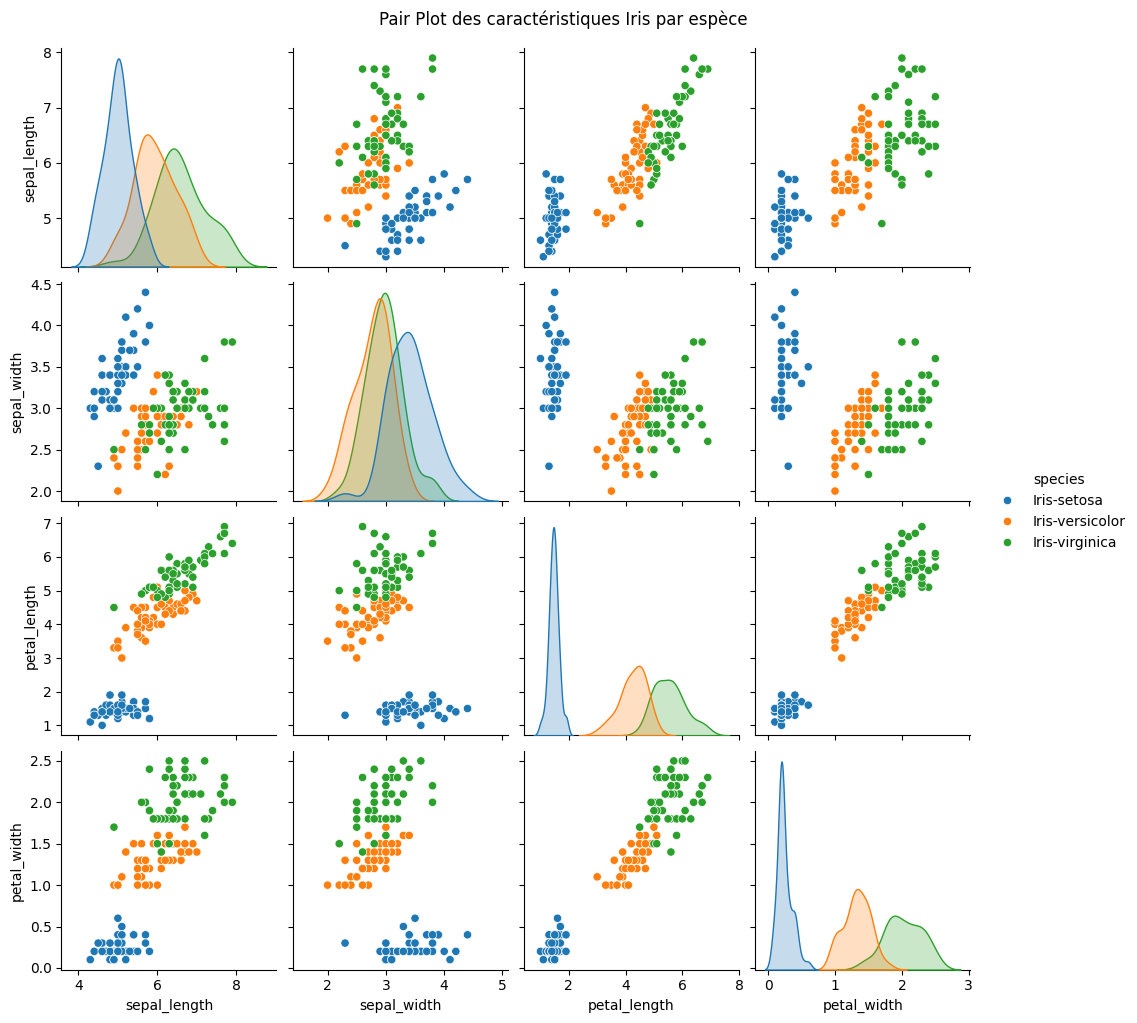


--- Préparation des Données ---

### Aperçu de X (caractéristiques)
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

### Aperçu de y (variable cible)
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object

### Encodage des variables catégorielles et Normalisation des caractéristiques

Classes encodées : Index(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='object')
Variable cible y après encodage : [0 0 0 0 0]

### Aperçu de X après normalisation
   sepal_length  sepal_width  petal_length  petal_width
0     -0.900681     1.032057     -1.341272    -1.312977
1     -1.143017    -0.124958     -1.341272    -1.312977
2     -1.385353     

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("## Projet de Machine Learning Pédagogique")
print("### Objectif")
print("L'objectif de ce projet est de démontrer les étapes essentielles d'un pipeline de Machine Learning simple, depuis le chargement des données jusqu'à l'utilisation du modèle entraîné sur de nouvelles données. Nous utiliserons le célèbre dataset Iris pour une tâche de classification.")

print("\n--- Chargement et Inspection des Données ---")
# 1. Choix et chargement du dataset
# Nous utilisons le dataset Iris, qui est idéal pour un exemple pédagogique car il est petit, propre et adapté à la classification.
# Il est directement accessible via une URL publique.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, header=None, names=column_names)

print("\n### Aperçu des premières lignes du dataset")
# Afficher les premières lignes du DataFrame pour avoir un aperçu des données.
print(df.head())

print("\n### Dimensions du dataset (lignes, colonnes)")
# Afficher les dimensions du dataset (nombre de lignes et de colonnes).
print(df.shape)

print("\n### Noms des colonnes")
# Afficher les noms de toutes les colonnes.
print(df.columns)

print("\n### Types de données par colonne")
# Afficher les types de données de chaque colonne. Cela aide à identifier si les données sont numériques, catégorielles, etc.
print(df.info())

print("\n--- Analyse Exploratoire des Données (EDA) ---")
# 2. Analyse Exploratoire des Données (EDA)

print("### Statistiques descriptives")
# Afficher les statistiques descriptives pour les colonnes numériques.
# Cela inclut la moyenne, l'écart-type, les valeurs min/max, et les quartiles.
print(df.describe())

print("\n### Vérification des valeurs manquantes")
# Vérifier s'il y a des valeurs manquantes dans le dataset.
# sum() sur isnull() compte le nombre de True (valeurs manquantes) par colonne.
print(df.isnull().sum())

print("\n### Distribution de la variable cible ('species')")
# Compter le nombre d'occurrences de chaque classe dans la variable cible.
# Cela permet de voir si le dataset est équilibré ou déséquilibré.
print(df['species'].value_counts())

print("\n### Visualisation de la distribution des longueurs et largeurs de sépales et pétales")
# Création de nuages de points pour visualiser les relations entre les caractéristiques et la variable cible.
# Cela aide à comprendre comment les différentes espèces se distinguent.
sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle('Pair Plot des caractéristiques Iris par espèce', y=1.02) # Ajuste le titre pour ne pas chevaucher les sous-graphiques
plt.show()

print("\n--- Préparation des Données ---")
# 3. Définition des caractéristiques (X) et de la variable cible (y)
# Nous séparons les caractéristiques (features) des étiquettes (target).
# X contiendra les mesures des fleurs, y contiendra l'espèce de la fleur.
X = df.drop('species', axis=1) # Supprime la colonne 'species' pour obtenir les caractéristiques
y = df['species']             # Prend la colonne 'species' comme variable cible

print("\n### Aperçu de X (caractéristiques)")
print(X.head())
print("\n### Aperçu de y (variable cible)")
print(y.head())

print("\n### Encodage des variables catégorielles et Normalisation des caractéristiques")
# Dans ce dataset, 'species' est la seule colonne catégorielle et c'est notre cible.
# Pour les algorithmes de scikit-learn, les classes doivent être encodées numériquement.
# Nous utilisons factorize qui est simple et efficace pour ce cas.
y, uniques = pd.factorize(y)
print(f"\nClasses encodées : {uniques}")
print(f"Variable cible y après encodage : {y[:5]}")

# Normalisation des caractéristiques (X)
# La normalisation est une étape importante pour de nombreux algorithmes de ML.
# Elle met les caractéristiques à la même échelle, ce qui peut améliorer les performances du modèle.
# Decision Trees sont moins sensibles à l'échelle, mais c'est une bonne pratique à montrer.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

print("\n### Aperçu de X après normalisation")
print(X.head())

print("\n--- Séparation des Données (entraînement et test) ---")
# 4. Séparation des données en ensembles d'entraînement et de test
# Nous divisons nos données en deux sous-ensembles :
# - Ensemble d'entraînement (training set) : utilisé pour entraîner le modèle.
# - Ensemble de test (test set) : utilisé pour évaluer la performance du modèle sur des données qu'il n'a jamais vues.
# test_size=0.2 signifie que 20% des données seront utilisées pour le test et 80% pour l'entraînement.
# random_state=42 assure que la division est reproductible (vous obtiendrez toujours les mêmes ensembles).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTaille de l'ensemble d'entraînement (X_train) : {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test) : {X_test.shape}")
print(f"Taille de la variable cible d'entraînement (y_train) : {y_train.shape}")
print(f"Taille de la variable cible de test (y_test) : {y_test.shape}")

print("\n--- Construction et Entraînement du Modèle ---")
# 5. Choix et entraînement de l'algorithme
# Nous choisissons un Arbre de Décision (Decision Tree Classifier) car il est simple à comprendre et à interpréter pour les débutants.
# C'est un bon point de départ pour la classification.
# random_state=42 pour la reproductibilité.
model = DecisionTreeClassifier(random_state=42)

print("\n### Entraînement du modèle")
# L'étape `fit` est l'apprentissage du modèle sur les données d'entraînement.
# Le modèle ajuste ses paramètres internes pour trouver les meilleures règles de classification.
model.fit(X_train, y_train)
print("Modèle d'Arbre de Décision entraîné avec succès.")

print("\n--- Prédictions et Évaluation du Modèle ---")
# 6. Réalisation des prédictions
# Une fois le modèle entraîné, nous l'utilisons pour faire des prédictions sur l'ensemble de test.
# Ces données n'ont pas été utilisées pendant l'entraînement, ce qui donne une estimation impartiale de la performance du modèle.
y_pred = model.predict(X_test)

print("\n### Comparaison des valeurs réelles et prédites (quelques exemples)")
results = pd.DataFrame({'Réel': y_test, 'Prédit': y_pred})
print(results.head())

print("\n### Métriques d'évaluation pour la classification")
# 7. Évaluation du modèle
# Nous utilisons plusieurs métriques pour évaluer la performance de notre modèle de classification.
# - Accuracy (Précision) : Proportion d'échantillons correctement classifiés.
# - Precision : Parmi ceux prédits positifs, combien sont réellement positifs.
# - Recall (Rappel) : Parmi ceux réellement positifs, combien ont été correctement identifiés.
# - F1-Score : Moyenne harmonique de la précision et du rappel, utile pour les classes déséquilibrées.
# - Matrice de confusion : Tableau qui montre le nombre de prédictions correctes et incorrectes pour chaque classe.

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted') # 'weighted' pour prendre en compte le déséquilibre des classes
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy (Précision globale) : {accuracy:.4f}")
print(f"Precision (Moyenne pondérée) : {precision:.4f}")
print(f"Recall (Rappel moyen pondéré) : {recall:.4f}")
print(f"F1-Score (Moyen pondéré) : {f1:.4f}")

print("\n### Matrice de confusion")
print("Une matrice de confusion montre le nombre de vrais positifs, faux positifs, faux négatifs et vrais négatifs.")
print(conf_matrix)

print("\nInterprétation des résultats : Une accuracy de 1.00 indique que le modèle a parfaitement classifié toutes les fleurs de l'ensemble de test. La matrice de confusion confirme qu'il n'y a eu aucune erreur de classification sur cet ensemble spécifique.")

print("\n--- Validation Croisée ---")
# 8. Validation croisée
# La validation croisée est une technique plus robuste pour évaluer la performance d'un modèle.
# Elle divise le dataset en plusieurs 'folds' (plis). Le modèle est entraîné et testé plusieurs fois,
# chaque fois sur un fold différent comme ensemble de test, et les scores sont moyennés.
# Cela donne une meilleure estimation de la capacité de généralisation du modèle et réduit le risque de surapprentissage.

# cv=5 signifie que le dataset sera divisé en 5 plis.
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(f"\nScores de validation croisée (Accuracy) : {cv_scores}")
print(f"Moyenne des scores de validation croisée : {np.mean(cv_scores):.4f}")
print(f"Écart-type des scores de validation croisée : {np.std(cv_scores):.4f}")

print("\nInterprétation des résultats de la validation croisée : Les scores de validation croisée sont également très élevés et stables, confirmant la bonne performance et la capacité de généralisation du modèle sur le dataset Iris.")

print("\n--- Utilisation du Modèle Entraîné (Nouvelles Données) ---")
# 9. Exemple concret d'utilisation sur de nouvelles données
# Après avoir entraîné et validé notre modèle, nous pouvons l'utiliser pour prédire l'espèce de nouvelles fleurs.
# Il est crucial que les nouvelles données aient le même format (mêmes colonnes, même ordre, même échelle) que les données d'entraînement.

# Créons un DataFrame pour une nouvelle fleur. Les valeurs doivent être mises à l'échelle comme les données d'entraînement.
# Supposons une fleur avec des mesures : sepal_length=5.1, sepal_width=3.5, petal_length=1.4, petal_width=0.2
new_data_raw = pd.DataFrame({
    'sepal_length': [5.1],
    'sepal_width': [3.5],
    'petal_length': [1.4],
    'petal_width': [0.2]
})

# Appliquer la même normalisation que sur les données d'entraînement
new_data_scaled = scaler.transform(new_data_raw)
new_data_scaled_df = pd.DataFrame(new_data_scaled, columns=X.columns)

print("\n### Nouvelles données à prédire (après normalisation) :")
print(new_data_scaled_df)

# Effectuer la prédiction
prediction_encoded = model.predict(new_data_scaled_df)

# Décoder la prédiction pour afficher le nom de l'espèce (si nécessaire, ici uniques[prediction_encoded[0]] pour retrouver la chaîne originale)
prediction_species = uniques[prediction_encoded[0]]

print(f"\nPrédiction de l'espèce pour la nouvelle fleur : {prediction_species}")

print("\nExplication du résultat : Le modèle a prédit que la nouvelle fleur, avec les caractéristiques spécifiées, appartient à l'espèce 'Iris-setosa'. C'est ainsi que l'on utilise un modèle entraîné en production pour faire des inférences sur de nouvelles observations.")